# 3. Field of 8 inclined boreholes with straight trajectories : (b) Convergence of geothermsim with regards to the discretization
The convergence of the model is evaluated by comparison with a solution obtained with a fine discretization.

In [1]:
# Import necessary packages
# Import packages for geothermsim
import geothermsim as gs
from jax import numpy as jnp

# Import packages for visualization
from matplotlib import pyplot as plt
import pandas as pd

### 3(b).1. Simulation parameters

In [2]:
# Borehole dimensions
D = 2.0             # Borehole buried depth (m)
L = 150.0           # Borehole length (m)
r_b = 0.075         # Borehole radius (m)
# Borehole spacings (m), tilt (deg), and inclinations (deg)
B = L * 0.025
tilt = jnp.radians(20.)
orientation = jnp.radians(jnp.array([180., 135., -135., 90., -90., 45., -45, 0.]))

# Pipe dimensions
r_out = 0.0211      # Pipe outer radius (m)
r_in = 0.0147       # Pipe inner radius (m)
D_s = 0.052         # Shank spacing (m)
epsilon = 2.12e-5   # Pipe roughness (m)

# Pipe positions
# Single U-tube : [[x_in, y_in], [x_out, y_out]]
p_pipes = jnp.array([[-D_s, 0.], [D_s, 0.]])

# Ground properties
alpha = 1.0e-6      # Ground thermal diffusivity (m2/s)
k_s = 2.0           # Ground thermal conductivity (W/m.K)

# Grout properties
k_b = 1.0           # Grout thermal conductivity (W/m.K)

# Pipe properties
k_p = 0.4           # Pipe thermal conductivity (W/m.K)

# Fluid properties
m_flow_borehole = 0.375 # Total fluid mass flow rate per borehole (kg/s)
m_flow_network = m_flow_borehole * len(orientation)
# The fluid is propylene-glycol (20 %) at 20 degC
cp_f = 3976.8       # Fluid specific heat capacity (in J/kg-K)
rho_f = 1014.8      # Fluid density (kg/m3)
mu_f = 2.0301e-3    # Fluid dynamic viscosity (kg/m.s)
k_f = 0.49221       # Fluid thermal conductivity (W/m.K)

The convergence of the solution is evaluated near steady-state, at $\ln(t/t_s)=5$.

In [3]:
ts = L**2 / (9 * alpha)    # Bore field characteristic time
lntts = jnp.array([5.])
time = jnp.exp(lntts) * ts

## 3(b).2. Reference solution
The reference solution is evaluated using $S=20$ segments of $N=11$ nodes (220 nodes in total).

In [4]:
N_ref = 11
S_ref = 20

basis = gs.Basis.Legendre(N_ref)
ground_heat_exchanger = gs.UTubeHeatExchanger(
    p_pipes, r_in, r_out, r_b, k_s, k_b, k_p, mu_f, rho_f, k_f, cp_f, epsilon)
R_d = ground_heat_exchanger.thermal_resistances
boreholes = []
for i, _orientation in enumerate(orientation):
    boreholes.append(
        gs.SingleUTube.from_dimensions(
            R_d, L, D, r_b, i * B, 0., basis, S_ref, tilt=tilt, orientation=_orientation))
borefield_reference = gs.Network(boreholes)

The `gFunction` object is initialized and the $g$-function is evaluated.

In [5]:
gfunc_reference = gs.gFunction(borefield_reference, m_flow_network, cp_f, time, alpha, k_s)
gfunc_reference.simulate()

Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.21 seconds.
Initialization end. Elapsed time: 2.23 seconds.
Simulation start.
Simulation end. Elapsed time: 2.23 seconds.


## 3(b).3. Convergence of geothermsim
The solution is evaluated for numbers of segments ranging from $1$ to $5$ and for numbers of nodes per segment ranging from $1$ to $11$.

The `Borefield` objects are first initialized for each discretization.

In [6]:
N_max = 11
S_max = 5
n = 0

borefields = []
for _S in range(1, S_max + 1):
    for _N in range(1, N_max + 1):
        basis = gs.Basis.Legendre(_N)
        boreholes = []
        for i, _orientation in enumerate(orientation):
            boreholes.append(
                gs.SingleUTube.from_dimensions(
                    R_d, L, D, r_b, i * B, 0., basis, _S, tilt=tilt, orientation=_orientation))
        borefields.append(gs.Network(boreholes))

The $g$-functions are then evaluated.

In [7]:
gfunc = [gs.gFunction(borefield, m_flow_network, cp_f, time, alpha, k_s) for borefield in borefields]

Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.13 seconds.
Initialization end. Elapsed time: 2.14 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.03 seconds.
Initialization end. Elapsed time: 2.04 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.04 seconds.
Initialization end. Elapsed time: 2.06 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.05 seconds.
Initialization end. Elapsed time: 2.06 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.07 seconds.
Initialization end. Elapsed time: 2.08 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.12 seconds.
Initialization end. Elapsed time: 2.14 seconds.
Initialization start.
Completed thermal response factors to nodes. Elapsed time: 2.15 seconds.
Initialization end. Elapsed time: 2.17 seconds.

In [8]:
for _gfunc in gfunc:
    _gfunc.simulate()
values = jnp.array([_gfunc.g[-1] for _gfunc in gfunc]).reshape(S_max, N_max).T

Simulation start.
Simulation end. Elapsed time: 0.62 seconds.
Simulation start.
Simulation end. Elapsed time: 0.49 seconds.
Simulation start.
Simulation end. Elapsed time: 0.50 seconds.
Simulation start.
Simulation end. Elapsed time: 0.57 seconds.
Simulation start.
Simulation end. Elapsed time: 0.53 seconds.
Simulation start.
Simulation end. Elapsed time: 0.47 seconds.
Simulation start.
Simulation end. Elapsed time: 0.47 seconds.
Simulation start.
Simulation end. Elapsed time: 0.44 seconds.
Simulation start.
Simulation end. Elapsed time: 0.49 seconds.
Simulation start.
Simulation end. Elapsed time: 0.49 seconds.
Simulation start.
Simulation end. Elapsed time: 0.48 seconds.
Simulation start.
Simulation end. Elapsed time: 0.52 seconds.
Simulation start.
Simulation end. Elapsed time: 0.42 seconds.
Simulation start.
Simulation end. Elapsed time: 0.38 seconds.
Simulation start.
Simulation end. Elapsed time: 0.39 seconds.
Simulation start.
Simulation end. Elapsed time: 0.41 seconds.
Simulati

In [9]:
# Format and print dataframe
df = pd.DataFrame(
    values,
    columns=[f'S = {_S}' for _S in jnp.arange(1, S_max + 1)],
    index=jnp.arange(1, N_max + 1))
df.index.name = 'N'
df.style.set_caption(r'$g$-Function at $ln(t/t_s)=5$') 

,S = 1,S = 2,S = 3,S = 4,S = 5
N,,,,,
1,12.877833,12.298955,12.080682,11.957511,11.875598
2,12.084943,11.808656,11.708848,11.656533,11.623462
3,11.811349,11.657575,11.603547,11.574363,11.557353
4,11.688233,11.591563,11.557904,11.542291,11.534640
5,11.622018,11.558984,11.538388,11.530087,11.525996
6,11.584895,11.541696,11.528890,11.523879,11.521098
7,11.562263,11.532401,11.523681,11.520171,11.517924
8,11.548526,11.526517,11.520219,11.517499,11.515517
9,11.539783,11.522624,11.517861,11.515521,11.513688


The relative error is calculated from the difference between the solution and the reference:
$$
\varepsilon_{rel} = \frac{g - g_{ref}}{g_{ref}}
$$

In [10]:
error = (jnp.array([_gfunc.g[-1] for _gfunc in gfunc]).reshape(S_max, N_max).T - gfunc_reference.g[-1]) / gfunc_reference.g[-1]

In [11]:
# Format and print dataframe
df = pd.DataFrame(
    error,
    columns=[f'S = {_S}' for _S in jnp.arange(1, S_max + 1)],
    index=jnp.arange(1, N_max + 1))
df.index.name = 'N'
df.style.set_caption(r'Relative error on the $g$-function at $ln(t/t_s)=5$') 

,S = 1,S = 2,S = 3,S = 4,S = 5
N,,,,,
1,0.119109,0.068803,0.049835,0.039131,0.032012
2,0.050205,0.026195,0.017522,0.012975,0.010101
3,0.026429,0.013066,0.008371,0.005834,0.004356
4,0.015730,0.007329,0.004404,0.003047,0.002383
5,0.009976,0.004498,0.002708,0.001987,0.001631
6,0.006750,0.002996,0.001883,0.001447,0.001206
7,0.004783,0.002188,0.001430,0.001125,0.000930
8,0.003589,0.001677,0.001129,0.000893,0.000721
9,0.002829,0.001338,0.000924,0.000721,0.000562


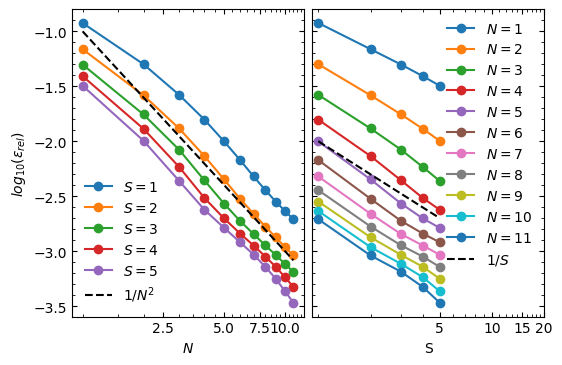

In [12]:
# Plot error as function of N and S
fig, axs = plt.subplots(ncols=2, sharey=True, layout='constrained')

N = jnp.arange(1, N_max + 1)
S = jnp.arange(1, S_max + 1)

axs[0].set_xscale('function', functions=(lambda x: jnp.log(x), lambda x: jnp.exp(x)))
axs[0] = gs.plot._format_axis(axs[0], axis_labels=[r'$N$', r'$log_{10}(\varepsilon_{rel})$'])
axs[0].plot(N, jnp.log10(error), '-o');
axs[0].plot(N, jnp.log10(0.1 / N**2), 'k--');
axs[0].legend([f'$S={_S}$' for _S in S] + [r'$1 / N^2$'], frameon=False)

axs[1].set_xscale('function', functions=(lambda x: jnp.log(x), lambda x: jnp.exp(x)))
axs[1] = gs.plot._format_axis(axs[1])
axs[1].set_xlabel(r'S')
axs[1].plot(S, jnp.log10(error.T), '-o');
axs[1].plot(S, jnp.log10(0.01 / S), 'k--');
axs[1].set_xlim(None, 20)
axs[1].legend([f'$N={_N}$' for _N in N] + [r'$1 / S$'], frameon=False)

fig.set_size_inches(140. / 25.4, 90. / 25.4)
fig.savefig('convergence-Eskilson-optimal.eps')